In [21]:
from xdl_densecaps.config import load_config
from xdl_densecaps.training import build_classifier, load_checkpoint, select_device, checkpoint_path
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os.path as osp

import torch
import torch.nn.functional as F
from torch import nn
from torchvision import transforms
from xdl_densecaps.datasets.binary_image_dataset import BinaryNormalLesionDataset
from torch.utils.data import DataLoader
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score


## HYPERPARAMS

In [22]:
config = load_config("configs/kvasir_v2_capsnet.yaml")
device = select_device(config.runtime.device)

In [23]:
TEST_DATA_DIR = config.data.root_dir
MODEL_PATH = osp.join(config.runtime.output_dir, "best.pt")

IMG_SIZE = 128
# IMG_SIZE = config.data.image_size
BATCH_SIZE = 16
# Attention map options: "grad_cam" or "channel_mean".
ATTENTION_MAP_METHOD = "grad_cam"
GRAD_CAM_LAYER = "denseblock4"  # Try "denseblock3" for a larger but less class-specific map.
GRAD_CAM_TARGET_CLASS = 1  # 0 = normal, 1 = lesion

# Grad-CAM is normalized to [0, 1], so 0.5 is a reasonable starting point.
BINARY_THRESHOLD = 0.6
BINARY_INVERT = False
MIN_AREA = 3

# Region filtering uses only correctly predicted samples by default.
FILTER_ONLY_CORRECT_PREDICTIONS = True
FILTER_MAX_K = 8
FILTER_RANDOM_STATE = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [24]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

dataset = BinaryNormalLesionDataset(root_dir=TEST_DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
test_batch = next(iter(dataloader))

test_data = test_batch[0].to(DEVICE)
test_labels = test_batch[1].to(DEVICE)

print(f"Batch shape: {test_batch[0].shape}")
print(f"Class counts: {dataset.class_counts()}")
print(f"Batch labels: {test_batch[1].tolist()}")

Batch shape: torch.Size([16, 3, 128, 128])
Class counts: {'normal': 3000, 'lesion': 3000}
Batch labels: [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0]


In [25]:
model = build_classifier(
    config,
    use_pretrained=False,
    use_backbone_checkpoint=False,
).to(device)

checkpoint = load_checkpoint(checkpoint_path(config), model, device)
model.eval()

with torch.no_grad():
    probs = model(test_data.to(device))

preds = probs.argmax(dim=1)


In [26]:
probs

tensor([[0.1882, 0.9165],
        [0.9395, 0.0568],
        [0.9043, 0.0711],
        [0.9638, 0.2958],
        [0.8171, 0.3369],
        [0.9560, 0.0938],
        [0.9095, 0.0592],
        [0.0750, 0.9632],
        [0.8526, 0.1421],
        [0.9666, 0.2029],
        [0.0799, 0.9654],
        [0.9606, 0.1085],
        [0.4572, 0.7561],
        [0.9333, 0.0881],
        [0.6845, 0.6004],
        [0.9279, 0.0750]])

In [27]:
preds, test_labels

(tensor([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0]),
 tensor([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0]))

In [28]:
model.backbone.eval()

DenseNet121FeatureExtractor(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [29]:
densenet_part = model.backbone
densenet_part.eval()

with torch.no_grad():
    features = densenet_part(test_data.to(device))
    # features = torch.relu(features)

print(features.shape)


torch.Size([16, 1024, 4, 4])


# Lesion Region candidates

## Attention map

`channel_mean` averages the DenseNet feature channels. `grad_cam` computes a class-specific Grad-CAM map from the selected DenseNet backbone layer.


In [30]:
AVAILABLE_GRAD_CAM_LAYERS = ["backbone", *dict(model.backbone.features.named_children()).keys()]
print("Available Grad-CAM layers:", AVAILABLE_GRAD_CAM_LAYERS)


def normalize_attention_map(attention_map: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Normalize each image map independently to [0, 1]."""
    if attention_map.dim() == 4 and attention_map.size(1) == 1:
        attention_map = attention_map[:, 0]
    if attention_map.dim() != 3:
        raise ValueError(f"Expected attention map [B, H, W], got {tuple(attention_map.shape)}")

    mins = attention_map.amin(dim=(1, 2), keepdim=True)
    maxs = attention_map.amax(dim=(1, 2), keepdim=True)
    return (attention_map - mins) / (maxs - mins + eps)


def upsample_attention_map(attention_map: torch.Tensor, image_size: tuple[int, int]) -> torch.Tensor:
    return F.interpolate(
        attention_map.unsqueeze(1),
        size=image_size,
        mode="bilinear",
        align_corners=False,
    ).squeeze(1)


def get_grad_cam_layer(model: nn.Module, layer_name: str) -> nn.Module:
    if layer_name == "backbone":
        return model.backbone

    layers = dict(model.backbone.features.named_children())
    if layer_name not in layers:
        raise ValueError(f"Unknown Grad-CAM layer {layer_name!r}. Options: {list(layers)} or 'backbone'.")
    return layers[layer_name]


def compute_grad_cam(
    model: nn.Module,
    images: torch.Tensor,
    target_class: int = 1,
    layer_name: str = "denseblock4",
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return low-res CAM, image-size CAM, and model scores."""
    model.eval()
    target_layer = get_grad_cam_layer(model, layer_name)

    activations: dict[str, torch.Tensor] = {}
    gradients: dict[str, torch.Tensor] = {}

    def save_activation(module, inputs, output):
        activations["value"] = output
        output.register_hook(lambda grad: gradients.__setitem__("value", grad))

    handle = target_layer.register_forward_hook(save_activation)
    try:
        model.zero_grad(set_to_none=True)
        scores = model(images)
        scores[:, target_class].sum().backward()
    finally:
        handle.remove()

    activation = activations["value"]
    gradient = gradients["value"]
    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * activation).sum(dim=1))
    cam = normalize_attention_map(cam)
    cam_up = upsample_attention_map(cam, images.shape[-2:])
    return cam.detach(), cam_up.detach(), scores.detach()


def build_attention_map() -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None]:
    if ATTENTION_MAP_METHOD == "channel_mean":
        attention_map = normalize_attention_map(features.mean(dim=1))
        attention_map_up = upsample_attention_map(attention_map, test_data.shape[-2:])
        return attention_map, attention_map_up, None

    if ATTENTION_MAP_METHOD == "grad_cam":
        return compute_grad_cam(
            model,
            test_data.to(device),
            target_class=GRAD_CAM_TARGET_CLASS,
            layer_name=GRAD_CAM_LAYER,
        )

    raise ValueError("ATTENTION_MAP_METHOD must be 'grad_cam' or 'channel_mean'.")


data_pooled, data_pooled_up, attention_scores = build_attention_map()

print("Attention method:", ATTENTION_MAP_METHOD)
if ATTENTION_MAP_METHOD == "grad_cam":
    print("Grad-CAM layer:", GRAD_CAM_LAYER)
    print("Target class:", GRAD_CAM_TARGET_CLASS)
print("Attention map:", data_pooled.shape)
print("Upsampled attention map:", data_pooled_up.shape)
print("Min/max:", float(data_pooled.min()), float(data_pooled.max()))


Available Grad-CAM layers: ['backbone', 'conv0', 'norm0', 'relu0', 'pool0', 'denseblock1', 'transition1', 'denseblock2', 'transition2', 'denseblock3', 'transition3', 'denseblock4']
Attention method: grad_cam
Grad-CAM layer: denseblock4
Target class: 1
Attention map: torch.Size([16, 4, 4])
Upsampled attention map: torch.Size([16, 128, 128])
Min/max: 0.0 0.9999999403953552


Then, we binarize it.

In [31]:
threshold_type = cv2.THRESH_BINARY_INV if BINARY_INVERT else cv2.THRESH_BINARY
_, data_binary = cv2.threshold(
    (data_pooled**2).detach().cpu().numpy(),
    BINARY_THRESHOLD,
    1,
    threshold_type,
)
data_binary = torch.from_numpy(data_binary).bool().to(DEVICE)

print("Binary masks:", data_binary.shape)
print("Active pixels per image:", data_binary.flatten(1).sum(dim=1).tolist())


Binary masks: torch.Size([16, 4, 4])
Active pixels per image: [2, 1, 0, 4, 2, 2, 0, 1, 0, 3, 4, 1, 3, 0, 1, 1]


Next, we can first visuualize the raw image, pooled, and binary data side by side to see the difference.

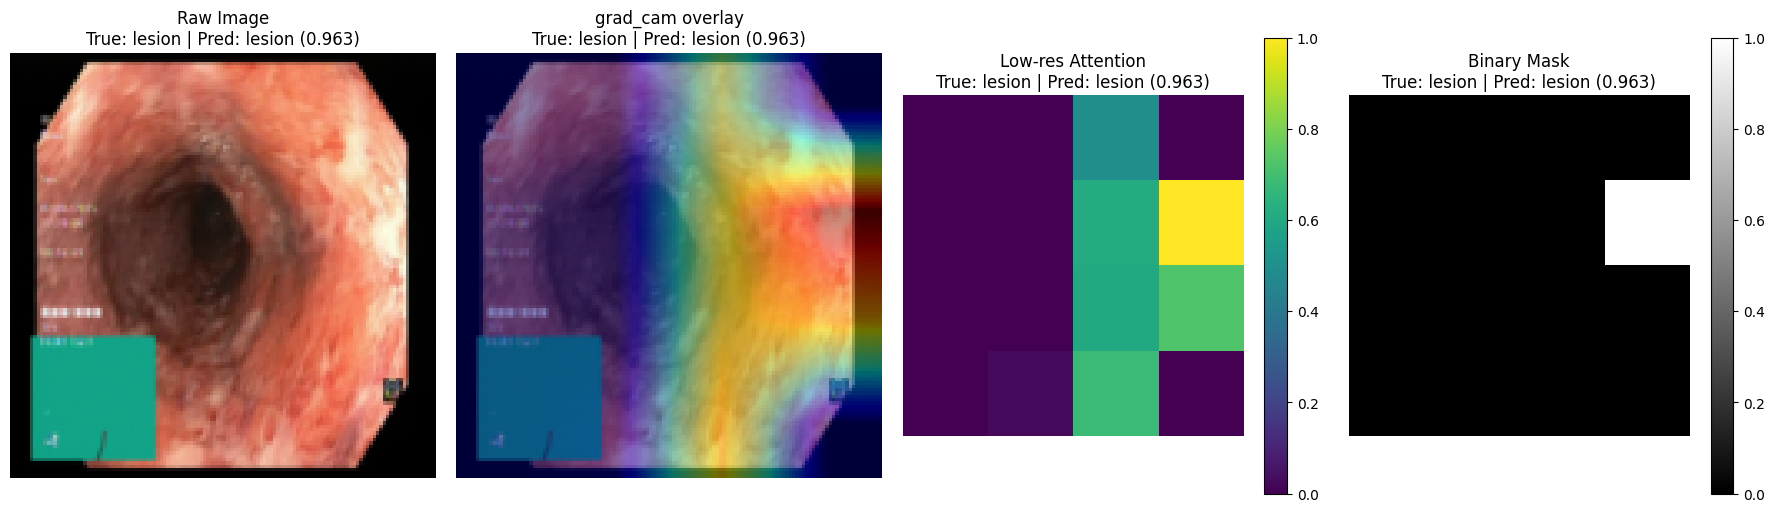

In [32]:
index = 7
img_binary = data_binary[index]
img_attention = data_pooled[index]
img_attention_up = data_pooled_up[index]
raw_img = test_data[index].permute(1, 2, 0)

true_class = dataset.class_names[int(test_labels[index].detach().cpu())]
pred_class = dataset.class_names[int(preds[index].detach().cpu())]
pred_score = float(probs[index, preds[index]].detach().cpu())
title_suffix = f"True: {true_class} | Pred: {pred_class} ({pred_score:.3f})"

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(raw_img.cpu().detach().numpy())
axs[0].set_title(f"Raw Image\n{title_suffix}")

axs[1].imshow(raw_img.cpu().detach().numpy())
axs[1].imshow(img_attention_up.cpu().detach().numpy(), cmap="jet", alpha=0.45, vmin=0, vmax=1)
axs[1].set_title(f"{ATTENTION_MAP_METHOD} overlay\n{title_suffix}")

attention_plot = axs[2].imshow((img_attention).cpu().detach().numpy(), cmap="viridis", vmin=0, vmax=1)
axs[2].set_title(f"Low-res Attention\n{title_suffix}")
fig.colorbar(attention_plot, ax=axs[2])

binary_plot = axs[3].imshow(img_binary.cpu().detach().numpy(), cmap="gray", vmin=0, vmax=1)
axs[3].set_title(f"Binary Mask\n{title_suffix}")
fig.colorbar(binary_plot, ax=axs[3])

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()


Next is check connectivity and aspect ratio

In [33]:
def _four_connected_neighbors(mask: torch.Tensor) -> torch.Tensor:
    neighbors = torch.zeros_like(mask, dtype=torch.bool)

    neighbors[1:, :] |= mask[:-1, :]
    neighbors[:-1, :] |= mask[1:, :]
    neighbors[:, 1:] |= mask[:, :-1]
    neighbors[:, :-1] |= mask[:, 1:]

    return neighbors


def _square_bbox_mask(
    binary_mask: torch.Tensor,
    y_min: torch.Tensor,
    x_min: torch.Tensor,
    y_max: torch.Tensor,
    x_max: torch.Tensor,
) -> torch.Tensor:
    height, width = binary_mask.shape
    device = binary_mask.device

    bbox_height = y_max - y_min + 1
    bbox_width = x_max - x_min + 1
    side = torch.maximum(bbox_height, bbox_width)

    max_side = torch.tensor(min(height, width), device=device, dtype=side.dtype)
    side = torch.minimum(side, max_side)

    y_start = y_min - (side - bbox_height) // 2
    x_start = x_min - (side - bbox_width) // 2

    zero = torch.zeros((), device=device, dtype=side.dtype)
    max_y_start = torch.tensor(height, device=device, dtype=side.dtype) - side
    max_x_start = torch.tensor(width, device=device, dtype=side.dtype) - side

    y_start = torch.minimum(torch.maximum(y_start, zero), max_y_start)
    x_start = torch.minimum(torch.maximum(x_start, zero), max_x_start)
    y_end = y_start + side - 1
    x_end = x_start + side - 1

    ys = torch.arange(height, device=device).view(-1, 1)
    xs = torch.arange(width, device=device).view(1, -1)
    return (ys >= y_start) & (ys <= y_end) & (xs >= x_start) & (xs <= x_end)


def separate_connected_components_as_square_boxes(
    binary_mask: torch.Tensor,
    aspect_ratio_threshold: float = 4.0,
    min_area: int = 2,
) -> torch.Tensor:
    """
    Returns square bool masks around each connected component.

    Args:
        binary_mask: 2D tensor [H, W].
        aspect_ratio_threshold: keeps component bboxes whose width / height is between
            1 / threshold and threshold.
        min_area: minimum component pixel count before creating a square box.

    Returns:
        Bool tensor [num_square_boxes, H, W].
    """
    if binary_mask.dim() != 2:
        raise ValueError(f"Expected a 2D mask [H, W], got shape {tuple(binary_mask.shape)}")

    binary_mask = binary_mask.bool()
    unvisited = binary_mask.clone()
    square_boxes = []

    while unvisited.any():
        seed_index = torch.nonzero(unvisited, as_tuple=False)[0]
        y, x = seed_index[0], seed_index[1]

        component = torch.zeros_like(binary_mask, dtype=torch.bool)
        frontier = torch.zeros_like(binary_mask, dtype=torch.bool)

        component[y, x] = True
        frontier[y, x] = True
        unvisited[y, x] = False

        while frontier.any():
            neighbors = _four_connected_neighbors(frontier)
            new_frontier = neighbors & unvisited

            if not new_frontier.any():
                break

            component |= new_frontier
            unvisited &= ~new_frontier
            frontier = new_frontier

        area = component.sum()
        if area < min_area:
            continue

        coords = torch.nonzero(component, as_tuple=False)
        y_min, x_min = coords.min(dim=0).values
        y_max, x_max = coords.max(dim=0).values

        width = (x_max - x_min + 1).float()
        height = (y_max - y_min + 1).float()
        aspect_ratio = width / height.clamp_min(1.0)

        if (
            aspect_ratio < aspect_ratio_threshold
            and aspect_ratio > 1.0 / aspect_ratio_threshold
        ):
            square_boxes.append(_square_bbox_mask(binary_mask, y_min, x_min, y_max, x_max))

    if not square_boxes:
        return torch.empty(
            (0, *binary_mask.shape),
            dtype=torch.bool,
            device=binary_mask.device,
        )

    return torch.stack(square_boxes, dim=0)


In [34]:
def resize_mask_to_input_image(
    square_mask: torch.Tensor,
    image_size: tuple[int, int],
) -> torch.Tensor:
    """Resize a low-resolution [h, w] bool mask to the input image [H, W]."""
    if square_mask.dim() != 2:
        raise ValueError(f"Expected square_mask [h, w], got {tuple(square_mask.shape)}")

    resized_mask = F.interpolate(
        square_mask.bool().float().unsqueeze(0).unsqueeze(0),
        size=image_size,
        mode="nearest",
    ).squeeze(0).squeeze(0)
    return resized_mask.bool()


def extract_zoomed_masked_input_image(
    input_image: torch.Tensor,
    square_mask: torch.Tensor,
    mode: str = "bilinear",
) -> tuple[torch.Tensor, torch.Tensor]:
    """Resize mask to input size, crop the masked region, then zoom it to [C, H, W]."""
    if input_image.dim() != 3:
        raise ValueError(f"Expected input_image [C, H, W], got {tuple(input_image.shape)}")

    image_mask = resize_mask_to_input_image(square_mask, input_image.shape[-2:])
    masked_image = input_image * image_mask.unsqueeze(0).to(dtype=input_image.dtype)

    coords = torch.nonzero(image_mask, as_tuple=False)
    if coords.numel() == 0:
        return torch.zeros_like(input_image), image_mask

    y_min, x_min = coords.min(dim=0).values.tolist()
    y_max, x_max = coords.max(dim=0).values.tolist()
    crop = masked_image[:, y_min : y_max + 1, x_min : x_max + 1]

    interpolate_kwargs = {"size": input_image.shape[-2:], "mode": mode}
    if mode in {"linear", "bilinear", "bicubic", "trilinear"}:
        interpolate_kwargs["align_corners"] = False
    zoomed_image = F.interpolate(crop.unsqueeze(0), **interpolate_kwargs).squeeze(0)
    return zoomed_image, image_mask


lesion_candidates = []
lesion_candidate_masks = []

for i, img in enumerate(data_binary):
    candidate_list = []
    mask_list = []
    les_cand = separate_connected_components_as_square_boxes(img, min_area=MIN_AREA)
    print(f"img idx-{i}: {len(les_cand)} components")
    if len(les_cand) == 0:
        lesion_candidates.append([])
        lesion_candidate_masks.append([])
        continue
    for mask in les_cand:
        masked_image, resized_mask = extract_zoomed_masked_input_image(test_data[i], mask)
        candidate_list.append(masked_image)
        mask_list.append(resized_mask)
    lesion_candidates.append(candidate_list) # shape: [batch][num_les_cand_per_img], each image is [3, 128, 128]
    lesion_candidate_masks.append(mask_list) # shape: [batch][num_les_cand_per_img], each mask is [128, 128]


img idx-0: 0 components
img idx-1: 0 components
img idx-2: 0 components
img idx-3: 1 components
img idx-4: 0 components
img idx-5: 0 components
img idx-6: 0 components
img idx-7: 0 components
img idx-8: 0 components
img idx-9: 1 components
img idx-10: 1 components
img idx-11: 0 components
img idx-12: 1 components
img idx-13: 0 components
img idx-14: 0 components
img idx-15: 0 components


## All Lesion Candidates

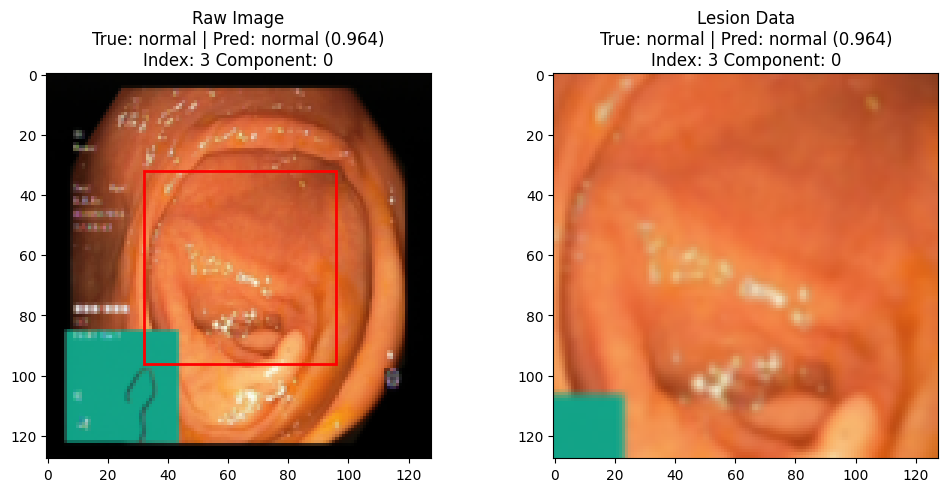

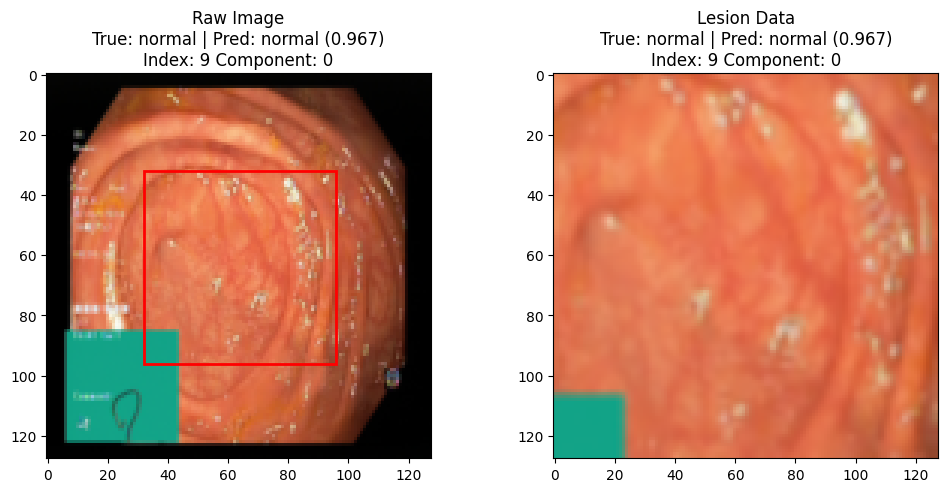

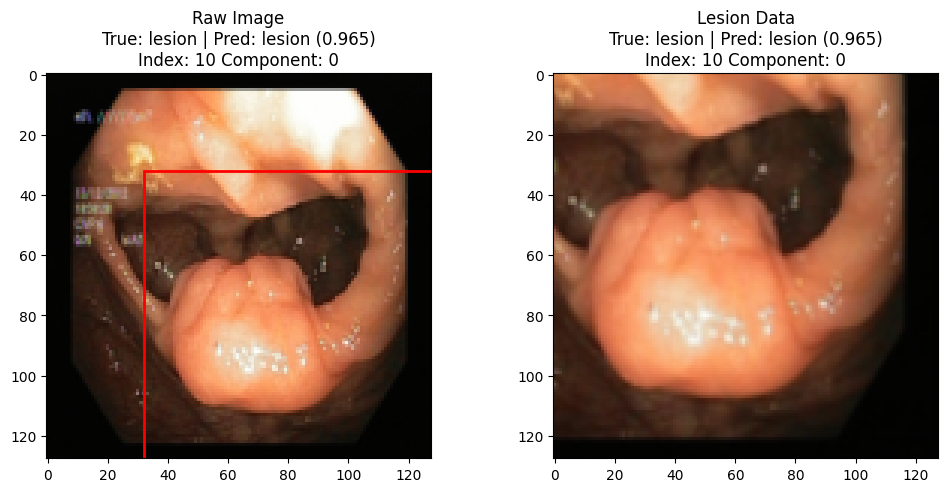

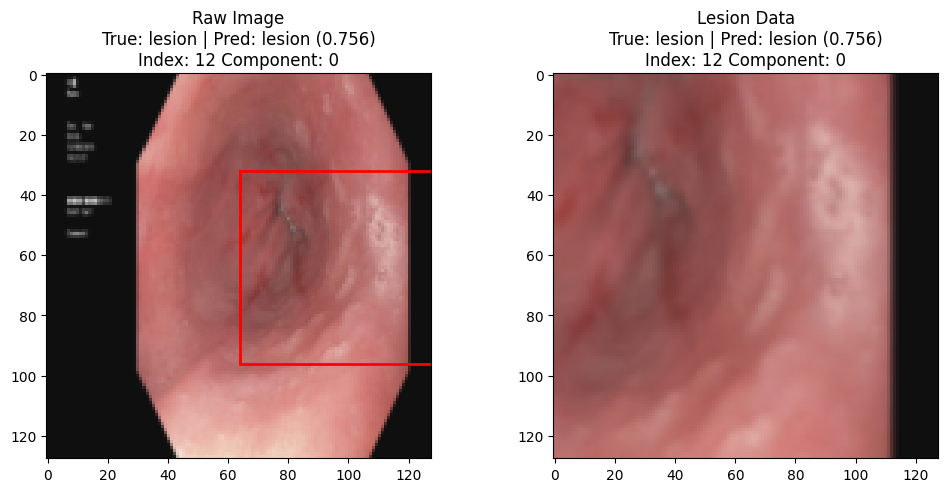

In [35]:
for index in range(len(lesion_candidates)):
    if len(lesion_candidates[index]) ==0:
        continue

    true_class = dataset.class_names[int(test_labels[index].detach().cpu())]
    pred_class = dataset.class_names[int(preds[index].detach().cpu())]
    pred_score = float(probs[index, preds[index]].detach().cpu())
    label_text = f"True: {true_class} | Pred: {pred_class} ({pred_score:.3f})"

    for candidate_index in range(len(lesion_candidates[index])):
        raw_img = test_data[index]
        lesion_img = lesion_candidates[index][candidate_index]
        lesion_mask = lesion_candidate_masks[index][candidate_index]
        raw_img = raw_img.permute(1, 2, 0)
        lesion_img = lesion_img.permute(1, 2, 0)

        coords = torch.nonzero(lesion_mask, as_tuple=False)
        y_min, x_min = coords.min(dim=0).values.tolist()
        y_max, x_max = coords.max(dim=0).values.tolist()
        box_width = x_max - x_min + 1
        box_height = y_max - y_min + 1

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        axs[0].imshow(raw_img.cpu().detach().numpy())
        axs[0].add_patch(
            Rectangle(
                (x_min, y_min),
                box_width,
                box_height,
                fill=False,
                edgecolor="red",
                linewidth=2,
            )
        )
        axs[0].set_title(f"Raw Image\n{label_text}\nIndex: {index} Component: {candidate_index}")
        axs[1].imshow(lesion_img.cpu().detach().numpy())
        axs[1].set_title(f"Lesion Data\n{label_text}\nIndex: {index} Component: {candidate_index}")
        plt.show()


In [36]:
test_labels

tensor([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0])

# Lesion Regions Filtering

In [37]:
# Pass each resized candidate through the DenseNet backbone, flatten it, and L2-normalize it.
def _class_name(label_tensor: torch.Tensor) -> str:
    return dataset.class_names[int(label_tensor.detach().cpu())]


def _candidate_feature(candidate_image: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        features = densenet_part(candidate_image.unsqueeze(0).to(device))
    features_flat = features.reshape(features.size(0), -1)
    return F.normalize(features_flat, p=2, dim=1).squeeze(0).detach().cpu()


def build_candidate_records() -> list[dict]:
    records = []

    for image_index, candidates in enumerate(lesion_candidates):
        true_label = int(test_labels[image_index].detach().cpu())
        pred_label = int(preds[image_index].detach().cpu())
        true_class = dataset.class_names[true_label]
        pred_class = dataset.class_names[pred_label]
        pred_score = float(probs[image_index, pred_label].detach().cpu())
        is_correct = true_label == pred_label

        for candidate_index, candidate_image in enumerate(candidates):
            records.append(
                {
                    "image_index": image_index,
                    "candidate_index": candidate_index,
                    "true_class": true_class,
                    "pred_class": pred_class,
                    "pred_score": pred_score,
                    "is_correct": is_correct,
                    "image": candidate_image.detach(),
                    "mask": lesion_candidate_masks[image_index][candidate_index].detach(),
                    "feature": _candidate_feature(candidate_image),
                }
            )

    return records


def _usable_record(record: dict) -> bool:
    return record["is_correct"] or not FILTER_ONLY_CORRECT_PREDICTIONS


candidate_records = build_candidate_records()
usable_candidate_records = [record for record in candidate_records if _usable_record(record)]
normal_candidate_records = [record for record in usable_candidate_records if record["true_class"] == "normal"]
lesion_candidate_records = [record for record in usable_candidate_records if record["true_class"] == "lesion"]

norm_normal_features = [record["feature"] for record in normal_candidate_records]
norm_lesion_features = [record["feature"] for record in lesion_candidate_records]

print(f"All candidate regions: {len(candidate_records)}")
print(f"Usable candidate regions: {len(usable_candidate_records)}")
print(f"Normal reference regions: {len(normal_candidate_records)}")
print(f"Lesion candidate regions: {len(lesion_candidate_records)}")


All candidate regions: 4
Usable candidate regions: 4
Normal reference regions: 2
Lesion candidate regions: 2


In [42]:
print(torch.__version__)

2.11.0+cpu


First, we build the k means clustering model to the norm_normal_features normalized vectors using Calinski–Harabasz (CH) method to determine the K most representative patterns.

In [38]:
# Build KMeans normal-reference centroids. K is selected with Calinski-Harabasz when possible.
def _stack_features(records: list[dict]) -> torch.Tensor:
    if not records:
        return torch.empty(0, 0)
    return torch.stack([record["feature"].float() for record in records], dim=0)


def choose_k_by_calinski_harabasz(
    feature_matrix: torch.Tensor,
    max_k: int,
    random_state: int,
) -> tuple[int, dict[int, float]]:
    num_samples = feature_matrix.size(0)
    if num_samples == 0:
        raise ValueError(
            "No usable normal candidate regions were found. "
            "Try a larger batch, lower BINARY_THRESHOLD/MIN_AREA, or inspect model predictions."
        )

    if num_samples < 3:
        return 1, {}

    max_valid_k = min(max_k, num_samples - 1)
    if max_valid_k < 2:
        return 1, {}

    features_np = feature_matrix.numpy()
    ch_scores = {}

    for k in range(2, max_valid_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = kmeans.fit_predict(features_np)
        if len(set(labels.tolist())) < 2:
            continue
        ch_scores[k] = float(calinski_harabasz_score(features_np, labels))

    if not ch_scores:
        return 1, {}

    best_k = max(ch_scores, key=ch_scores.get)
    return best_k, ch_scores


normal_feature_matrix = _stack_features(normal_candidate_records)
selected_k, ch_scores = choose_k_by_calinski_harabasz(
    normal_feature_matrix,
    max_k=FILTER_MAX_K,
    random_state=FILTER_RANDOM_STATE,
)

normal_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=FILTER_RANDOM_STATE,
    n_init="auto",
)
normal_kmeans.fit(normal_feature_matrix.numpy())

normal_centroids = torch.from_numpy(normal_kmeans.cluster_centers_).float()
normal_centroids = F.normalize(normal_centroids, p=2, dim=1)

print(f"Selected K: {selected_k}")
if ch_scores:
    print("CH scores:", {k: round(score, 3) for k, score in ch_scores.items()})
print("Normal centroids:", normal_centroids.shape)


Selected K: 1
Normal centroids: torch.Size([1, 16384])


Then using cosine simiarity, we then find the similarity index for each candidate region using the norm_lesion_features to each of the centroids. Then we sum up the cosine similarity for each lesion candidate region and we only take the candidate region of that image with the smallest similarity index.

In [39]:
# Score lesion candidates against normal centroids and keep the least-normal region per lesion image.
def normal_similarity_score(feature: torch.Tensor, centroids: torch.Tensor) -> tuple[float, torch.Tensor]:
    similarities = torch.matmul(centroids, feature.float())
    return float(similarities.sum().item()), similarities.detach().cpu()


def select_best_lesion_regions(
    records: list[dict],
    centroids: torch.Tensor,
) -> tuple[dict[int, dict], list[dict]]:
    best_by_image = {}
    scored_records = []

    for record in records:
        score, centroid_similarities = normal_similarity_score(record["feature"], centroids)
        scored_record = {
            **record,
            "score": score,
            "centroid_similarities": centroid_similarities,
        }
        scored_records.append(scored_record)

        image_index = scored_record["image_index"]
        current_best = best_by_image.get(image_index)
        if current_best is None or scored_record["score"] < current_best["score"]:
            best_by_image[image_index] = scored_record

    return best_by_image, scored_records


filtered_lesion_regions, scored_lesion_candidates = select_best_lesion_regions(
    lesion_candidate_records,
    normal_centroids,
)

print(f"Scored lesion candidates: {len(scored_lesion_candidates)}")
print(f"Images with selected lesion region: {len(filtered_lesion_regions)}")

for image_index, result in filtered_lesion_regions.items():
    print(
        f"image={image_index} candidate={result['candidate_index']} "
        f"score={result['score']:.4f} true={result['true_class']} pred={result['pred_class']}"
    )


Scored lesion candidates: 2
Images with selected lesion region: 2
image=10 candidate=0 score=0.4209 true=lesion pred=lesion
image=12 candidate=0 score=0.8525 true=lesion pred=lesion


## Results visualization

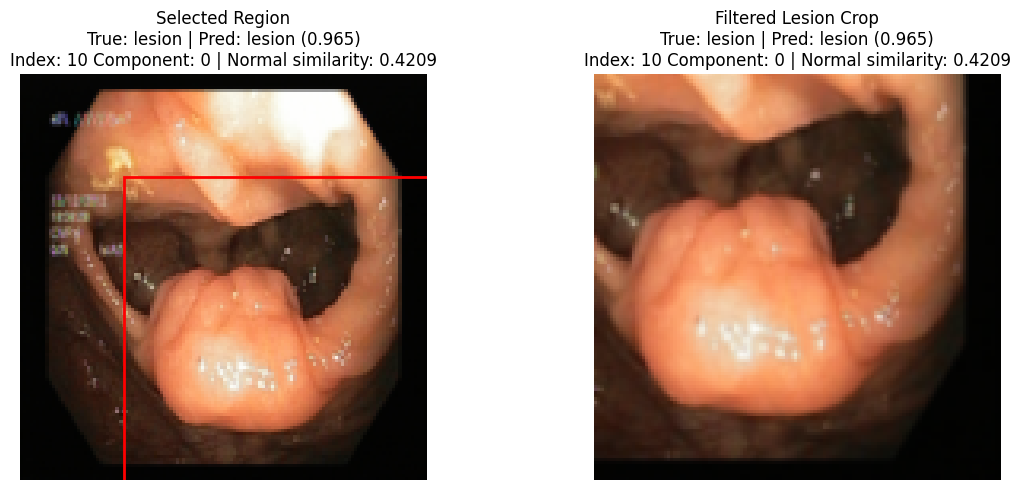

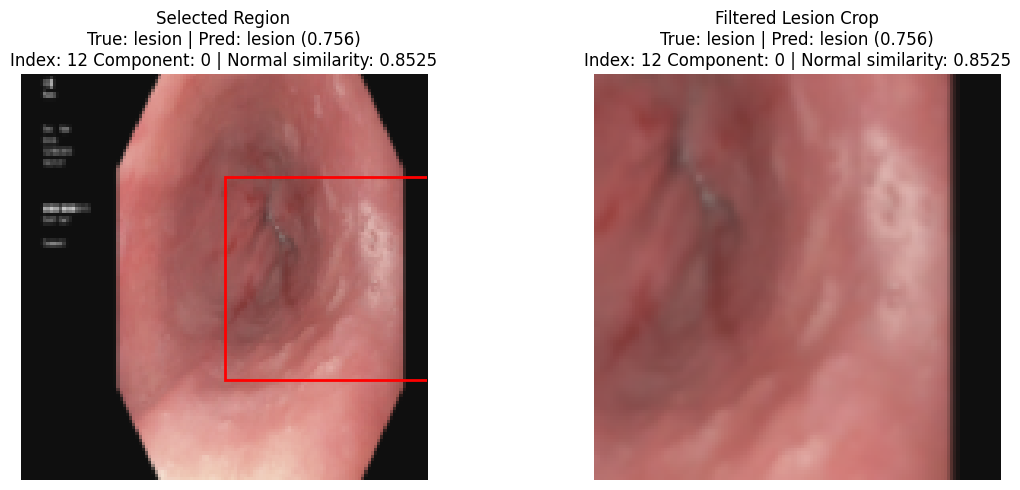

In [40]:
# Visualize the selected lesion region for each eligible image.
if not filtered_lesion_regions:
    print("No filtered lesion regions to visualize.")

for image_index, result in filtered_lesion_regions.items():
    raw_img = test_data[image_index].permute(1, 2, 0)
    lesion_img = result["image"].permute(1, 2, 0)
    lesion_mask = result["mask"]

    coords = torch.nonzero(lesion_mask, as_tuple=False)
    if coords.numel() == 0:
        print(f"Skipping image {image_index}: selected mask is empty.")
        continue

    y_min, x_min = coords.min(dim=0).values.tolist()
    y_max, x_max = coords.max(dim=0).values.tolist()
    box_width = x_max - x_min + 1
    box_height = y_max - y_min + 1

    title_text = (
        f"True: {result['true_class']} | Pred: {result['pred_class']} ({result['pred_score']:.3f})\n"
        f"Index: {image_index} Component: {result['candidate_index']} | Normal similarity: {result['score']:.4f}"
    )

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(raw_img.cpu().detach().numpy())
    axs[0].add_patch(
        Rectangle(
            (x_min, y_min),
            box_width,
            box_height,
            fill=False,
            edgecolor="red",
            linewidth=2,
        )
    )
    axs[0].set_title(f"Selected Region\n{title_text}")
    axs[0].axis("off")

    axs[1].imshow(lesion_img.cpu().detach().numpy())
    axs[1].set_title(f"Filtered Lesion Crop\n{title_text}")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()
